<a href="https://colab.research.google.com/github/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/blob/main/Faisal_churn_prediction_ann_h5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction — ANN (Binary Classification)

## 1. Problem Definition

**Objective:** Predict whether a customer will leave (churn) a telecom service using an Artificial Neural Network.

**Dataset:** [Telco Customer Churn (IBM / Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 records × 21 features.

**Approach:**
- Build a **baseline ANN** → identify weaknesses (low recall)
- Build an **advanced ANN** with regularization (L2, Dropout, Early Stopping), class weighting, and manual hyperparameter tuning
- Compare baseline vs advanced model on Accuracy, Precision, Recall, F1, ROC-AUC
- Save the best model and create an inference function

**Author:** Faisal

## 2. Imports & Setup

In [1]:
# =========================
# IMPORTS 
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

## 3. Data Loading & Exploration

In [2]:
url = "https://raw.githubusercontent.com/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [4]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [7]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

##  Churn Distribution Analysis


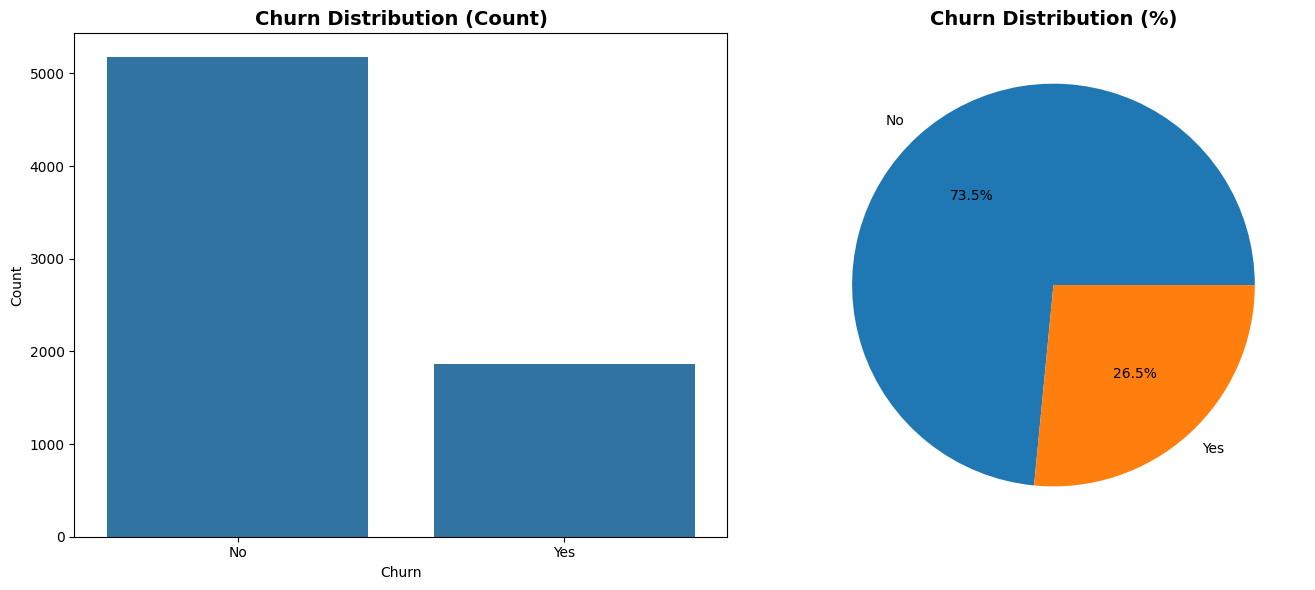

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ======================
# Bar Plot
# ======================
sns.countplot(x="Churn", data=df, ax=axes[0])
axes[0].set_title("Churn Distribution (Count)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Count")

# ======================
# Pie Chart
# ======================
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)
axes[1].set_title("Churn Distribution (%)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Correlation Heatmap

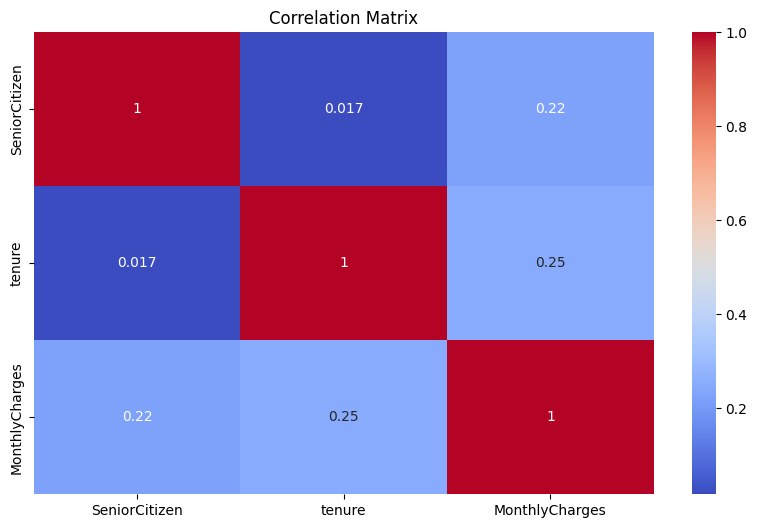

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 4. Data Preprocessing

In [14]:
# ================================
# DATA PREPROCESSING
# ================================


# 1) Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# 2) Drop useless column
df.drop("customerID", axis=1, inplace=True)

# 3) Convert target to 0/1
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4) Convert binary categorical columns to 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "gender"]

for col in binary_cols:
    df[col] = df[col].map({
        "No": 0, "Yes": 1,
        "Female": 0, "Male": 1
    })

# 5) Replace service-related special labels
replace_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies"
]

for col in replace_cols:
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

# 6) Feature engineering
df["AvgCharge"] = df["TotalCharges"] / (df["tenure"] + 1)

# 7) One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# 8) Convert boolean columns to 0/1
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# 9) Apply scaling only to continuous numerical columns
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgCharge"]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

# 10) Final check
print("Final Shape:", df.shape)

Final Shape: (7043, 25)


In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,0,1,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,0,1,1,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,0,0,0,0,0,0,0,0,1,0


## 5. Model Design

### 5.1 Baseline ANN Model

In [16]:
# ================================
# BASELINE ANN MODEL
# ================================


# Split features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build baseline model
baseline_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train baseline model
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict
y_prob = baseline_model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7777 - loss: 0.4797 - val_accuracy: 0.7791 - val_loss: 0.4479
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8001 - loss: 0.4213 - val_accuracy: 0.7817 - val_loss: 0.4411
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8034 - loss: 0.4147 - val_accuracy: 0.7808 - val_loss: 0.4388
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8074 - loss: 0.4099 - val_accuracy: 0.7933 - val_loss: 0.4413
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8076 - loss: 0.4083 - val_accuracy: 0.7924 - val_loss: 0.4361
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - loss: 0.4054 - val_accuracy: 0.7924 - val_loss: 0.4358
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8103 - loss: 0.4035 - val_accuracy: 0.7826 - val_loss: 0.4408
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8118 - loss: 0.4022 - val_accuracy: 0.

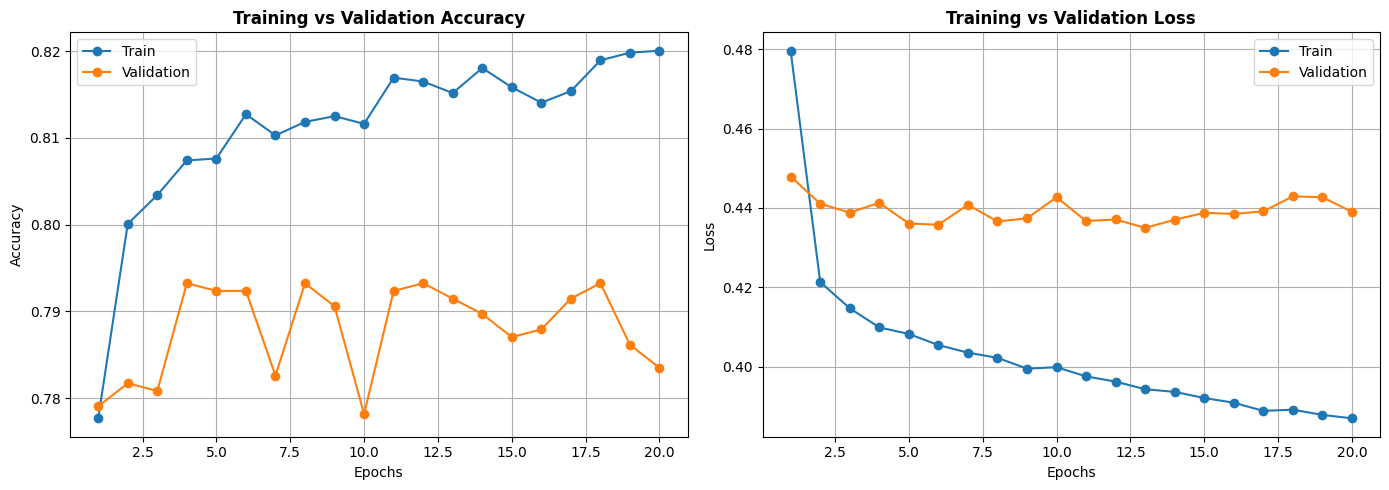

In [17]:

# ======================
# Extract history
# ======================
acc = history_baseline.history["accuracy"]
val_acc = history_baseline.history["val_accuracy"]

loss = history_baseline.history["loss"]
val_loss = history_baseline.history["val_loss"]

epochs = range(1, len(acc) + 1)

# ======================
# Plot
# ======================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(epochs, acc, marker='o')
axes[0].plot(epochs, val_acc, marker='o')
axes[0].set_title("Training vs Validation Accuracy", fontweight="bold")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend(["Train", "Validation"])
axes[0].grid()

# Loss Plot
axes[1].plot(epochs, loss, marker='o')
axes[1].plot(epochs, val_loss, marker='o')
axes[1].set_title("Training vs Validation Loss", fontweight="bold")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend(["Train", "Validation"])
axes[1].grid()

plt.tight_layout()
plt.show()

### Baseline Model Analysis

The training accuracy increases steadily, while validation accuracy remains nearly constant around 78–79%. Training loss decreases, but validation loss does not improve.

This indicates overfitting, where the model performs well on training data but fails to generalize to new data.

To improve the model, techniques such as Dropout, L2 regularization, and EarlyStopping can be applied.

## 6. Training & Tuning — Advanced Model

### 6.1 Prepare Data with Class Weights

In [18]:
# ================================
# PREPARE DATA FOR ADVANCED MODEL
# ================================

X = df.drop("Churn", axis=1).values
y = df["Churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights = dict(zip(classes, weights))

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Class weights:", class_weights)

X_train: (5634, 24)
X_test : (1409, 24)
Class weights: {np.int64(0): np.float64(0.6805991785455424), np.int64(1): np.float64(1.8842809364548494)}


### 6.2 Hyperparameter Search Space

In [19]:
# ================================
# HYPERPARAMETER SEARCH SPACE
# ================================

learning_rates = [ 0.001, 0.0001]
dropout_rates = [0.3, 0.4]
batch_sizes = [32, 64]
l2_values = [0.001, 0.01]

optimizers_list = [
    ("adam", lambda lr: tf.keras.optimizers.Adam(learning_rate=lr)),
    ("rmsprop", lambda lr: tf.keras.optimizers.RMSprop(learning_rate=lr)),
    ("sgd_momentum", lambda lr: tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9))
]

total_combinations = (
    len(learning_rates)
    * len(dropout_rates)
    * len(batch_sizes)
    * len(l2_values)
    * len(optimizers_list)
)

print("Learning Rates :", learning_rates)
print("Dropout Rates  :", dropout_rates)
print("Batch Sizes    :", batch_sizes)
print("L2 Values      :", l2_values)
print("Optimizers     :", [opt[0] for opt in optimizers_list])
print("Total combinations to test:", total_combinations)

Learning Rates : [0.001, 0.0001]
Dropout Rates  : [0.3, 0.4]
Batch Sizes    : [32, 64]
L2 Values      : [0.001, 0.01]
Optimizers     : ['adam', 'rmsprop', 'sgd_momentum']
Total combinations to test: 48


### 6.3 Model Builder Function (with Regularization)

In [20]:
# ================================
# MODEL BUILDER (WITH HYPERPARAMETERS)
# ================================



def build_model(input_dim, lr, dropout_rate, l2_value, optimizer_fn):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.Dropout(dropout_rate),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_value)
        ),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer_fn(lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc")
        ]
    )

    return model

### 6.4 Run Hyperparameter Tuning (5-Fold Cross-Validation)

In [21]:
# ================================
# RUN HYPERPARAMETER TUNING
# ================================


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_score = -1
best_config = None

for opt_name, opt_fn in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            for dr in dropout_rates:
                for l2_val in l2_values:

                    fold_scores = []

                    for train_idx, val_idx in kf.split(X_train, y_train):
                        X_tr, X_val = X_train[train_idx], X_train[val_idx]
                        y_tr, y_val = y_train[train_idx], y_train[val_idx]

                        model = build_model(
                            input_dim=X_train.shape[1],
                            lr=lr,
                            dropout_rate=dr,
                            l2_value=l2_val,
                            optimizer_fn=opt_fn
                        )

                        early_stop = EarlyStopping(
                            monitor="val_loss",
                            patience=3,
                            restore_best_weights=True
                        )

                        model.fit(
                            X_tr, y_tr,
                            validation_data=(X_val, y_val),
                            epochs=25,
                            batch_size=batch,
                            class_weight=class_weights,
                            callbacks=[early_stop],
                            verbose=0
                        )

                        y_prob = model.predict(X_val, verbose=0).ravel()
                        y_pred = (y_prob >= 0.5).astype(int)

                        f1 = f1_score(y_val, y_pred)
                        auc = roc_auc_score(y_val, y_prob)

                        fold_scores.append((f1 + auc) / 2)

                    avg_score = np.mean(fold_scores)

                    print(f"{opt_name} | LR={lr}, Batch={batch}, Dropout={dr}, L2={l2_val} -> Score={avg_score:.4f}")

                    results.append({
                        "optimizer": opt_name,
                        "learning_rate": lr,
                        "batch_size": batch,
                        "dropout": dr,
                        "l2": l2_val,
                        "score": avg_score
                    })

                    if avg_score > best_score:
                        best_score = avg_score
                        best_config = {
                            "optimizer": opt_name,
                            "learning_rate": lr,
                            "batch_size": batch,
                            "dropout": dr,
                            "l2": l2_val
                        }

adam | LR=0.001, Batch=32, Dropout=0.3, L2=0.001 -> Score=0.7393
adam | LR=0.001, Batch=32, Dropout=0.3, L2=0.01 -> Score=0.7396
adam | LR=0.001, Batch=32, Dropout=0.4, L2=0.001 -> Score=0.7409
adam | LR=0.001, Batch=32, Dropout=0.4, L2=0.01 -> Score=0.7391
adam | LR=0.001, Batch=64, Dropout=0.3, L2=0.001 -> Score=0.7380
adam | LR=0.001, Batch=64, Dropout=0.3, L2=0.01 -> Score=0.7403
adam | LR=0.001, Batch=64, Dropout=0.4, L2=0.001 -> Score=0.7383
adam | LR=0.001, Batch=64, Dropout=0.4, L2=0.01 -> Score=0.7421
adam | LR=0.0001, Batch=32, Dropout=0.3, L2=0.001 -> Score=0.7375
adam | LR=0.0001, Batch=32, Dropout=0.3, L2=0.01 -> Score=0.7390
adam | LR=0.0001, Batch=32, Dropout=0.4, L2=0.001 -> Score=0.7356
adam | LR=0.0001, Batch=32, Dropout=0.4, L2=0.01 -> Score=0.7372
adam | LR=0.0001, Batch=64, Dropout=0.3, L2=0.001 -> Score=0.7353
adam | LR=0.0001, Batch=64, Dropout=0.3, L2=0.01 -> Score=0.7366
adam | LR=0.0001, Batch=64, Dropout=0.4, L2=0.001 -> Score=0.7376
adam | LR=0.0001, Batch=6

### 6.5 Best Tuning Results

In [22]:
# ================================
# SHOW BEST TUNING RESULTS
# ================================


results_df = pd.DataFrame(results).sort_values(by="score", ascending=False).reset_index(drop=True)

print("Best Config:")
print(best_config)

print("\nBest Score:")
print(round(best_score, 4))

print("\nTop 10 Results:")
results_df.head(10)

Best Config:
{'optimizer': 'rmsprop', 'learning_rate': 0.001, 'batch_size': 64, 'dropout': 0.3, 'l2': 0.01}

Best Score:
0.7423

Top 10 Results:


,optimizer,learning_rate,batch_size,dropout,l2,score
0,rmsprop,0.001,64,0.3,0.010,0.742262
1,adam,0.001,64,0.4,0.010,0.742092
2,rmsprop,0.001,64,0.4,0.010,0.740914
3,adam,0.001,32,0.4,0.001,0.740901
4,rmsprop,0.001,32,0.3,0.001,0.740518
5,rmsprop,0.001,64,0.4,0.001,0.740391
6,adam,0.001,64,0.3,0.010,0.740253
7,rmsprop,0.001,32,0.4,0.001,0.739687
8,adam,0.001,32,0.3,0.010,0.739597
9,sgd_momentum,0.001,32,0.4,0.010,0.739580


### 6.6 Train Final Model with Best Configuration

In [23]:
# ================================
# TRAIN FINAL MODEL WITH BEST CONFIG
# ================================


# Choose optimizer based on best_config
if best_config["optimizer"] == "adam":
    optimizer = tf.keras.optimizers.Adam(learning_rate=best_config["learning_rate"])
elif best_config["optimizer"] == "rmsprop":
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=best_config["learning_rate"])
else:
    optimizer = tf.keras.optimizers.SGD(
        learning_rate=best_config["learning_rate"],
        momentum=0.9
    )

# Build model
final_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(best_config["l2"])),
    layers.Dropout(best_config["dropout"]),

    layers.Dense(64, activation="relu",
                 kernel_regularizer=regularizers.l2(best_config["l2"])),
    layers.Dropout(best_config["dropout"]),

    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

final_model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train
history_final = final_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=best_config["batch_size"],
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7096 - auc: 0.7924 - loss: 1.3724 - val_accuracy: 0.7303 - val_auc: 0.8219 - val_loss: 1.0614
Epoch 2/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7586 - auc: 0.8290 - loss: 0.8656 - val_accuracy: 0.7320 - val_auc: 0.8244 - val_loss: 0.7567
Epoch 3/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - auc: 0.8339 - loss: 0.6808 - val_accuracy: 0.6974 - val_auc: 0.8244 - val_loss: 0.7102
Epoch 4/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7604 - auc: 0.8409 - loss: 0.6022 - val_accuracy: 0.7365 - val_auc: 0.8276 - val_loss: 0.5915
Epoch 5/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7604 - auc: 0.8428 - loss: 0.5662 - val_accuracy: 0.7427 - val_auc: 0.8272 - val_loss: 0.5532
Epoch 6/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7531 - auc: 0.8400 - loss: 0.5530 - val_accuracy: 0.7178 - val_auc: 0.8269 - val_loss: 0.5874
Epoch 7/25
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

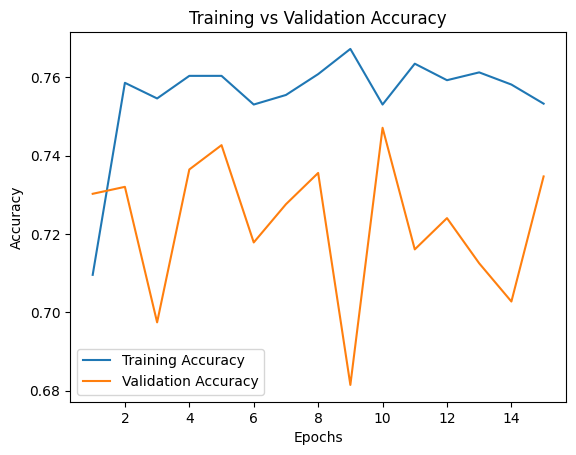

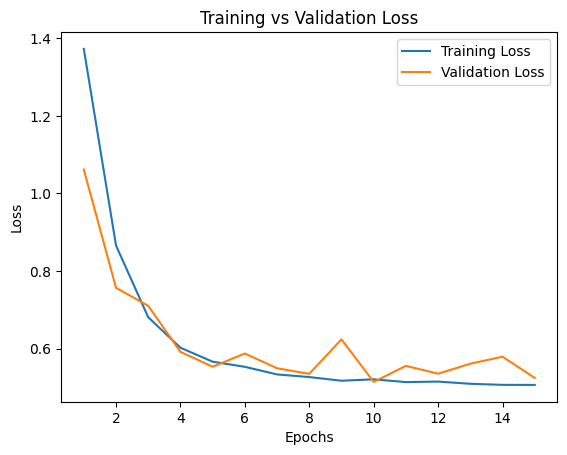

In [24]:
# ================================
# PLOT TRAINING HISTORY
# ================================

# Extract values
loss = history_final.history["loss"]
val_loss = history_final.history["val_loss"]

accuracy = history_final.history["accuracy"]
val_accuracy = history_final.history["val_accuracy"]

epochs = range(1, len(loss) + 1)
# --------------------
# ACCURACY PLOT
# --------------------
plt.figure()

plt.plot(epochs, accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# --------------------
# LOSS PLOT
# --------------------
plt.figure()

plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()




## 7. Evaluation — Baseline vs Advanced Comparison

In [27]:
# ================================
# BASELINE VS ADVANCED COMPARISON
# ================================

# Baseline predictions
y_prob_base = baseline_model.predict(X_test).ravel()
y_pred_base = (y_prob_base >= 0.5).astype(int)

# Advanced predictions
y_prob_adv = final_model.predict(X_test).ravel()
y_pred_adv = (y_prob_adv >= 0.5).astype(int)

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Baseline", "Advanced"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_adv)
    ],
    "Precision": [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_adv)
    ],
    "Recall": [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_adv)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_adv)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_adv)
    ]
})

comparison

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 853us/step


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.791341,0.619048,0.556150,0.585915,0.844114
1,Advanced,0.763662,0.540755,0.727273,0.620296,0.844571


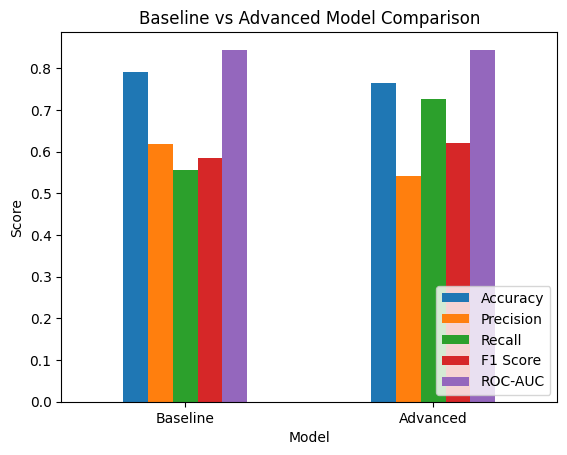

In [28]:
# ================================
# BAR CHART COMPARISON
# ================================

import matplotlib.pyplot as plt

comparison.set_index("Model").plot(kind="bar")

plt.title("Baseline vs Advanced Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

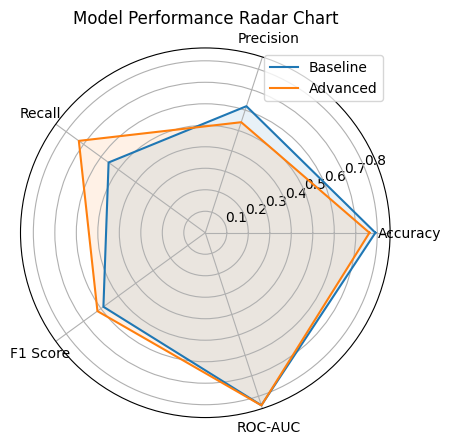

In [30]:
import numpy as np

labels = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

baseline_values = comparison.iloc[0, 1:].values
advanced_values = comparison.iloc[1, 1:].values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

baseline_values = np.concatenate([baseline_values, [baseline_values[0]]])
advanced_values = np.concatenate([advanced_values, [advanced_values[0]]])

plt.figure()
ax = plt.subplot(111, polar=True)

ax.plot(angles, baseline_values, label="Baseline")
ax.plot(angles, advanced_values, label="Advanced")

ax.fill(angles, baseline_values, alpha=0.1)
ax.fill(angles, advanced_values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Model Performance Radar Chart")
plt.legend()

plt.show()

###  Model Evaluation Analysis

The comparison between the baseline and advanced models highlights a clear trade-off in performance metrics.

The **advanced model achieved a substantial improvement in recall**, increasing from **0.56 to 0.73**, which indicates a significantly better ability to correctly identify customers who are likely to churn.

Although the **precision decreased** (from 0.62 to 0.54), this trade-off is expected and acceptable in churn prediction scenarios. In such cases, **missing a true churn customer (false negative)** is more costly than incorrectly predicting churn for a non-churn customer (false positive).

Moreover, the **F1-score improved** from **0.586 to 0.620**, showing a better balance between precision and recall in the advanced model.

The **ROC-AUC remained consistent (~0.84)** for both models, indicating that both models have a similar overall ability to distinguish between classes. However, the advanced model provides better performance in the metric that matters most for this problem (recall).

### Conclusion

Overall, the advanced model is more suitable for churn prediction tasks, as it prioritizes capturing high-risk customers, which is critical for business decision-making and customer retention strategies.

## 8. Model Saving & Loading

In [32]:
# ================================
# SAVE FINAL MODEL
# ================================

final_model.save("telco_churn_final_model.h5")
print("Model saved successfully as telco_churn_final_model.h5")

Model saved successfully as telco_churn_final_model.h5


## 9. Inference Pipeline

In [33]:
# ================================
# LOAD MODEL + INFERENCE FUNCTION
# ================================

loaded_model = keras.models.load_model("telco_churn_final_model.h5")

def predict_churn(sample, model=loaded_model, threshold=0.5):
    """
    Predict churn for one sample or multiple samples.

    Parameters:
    sample: array-like with shape (n_features,) or (n_samples, n_features)
    model: trained keras model
    threshold: probability threshold for classification

    Returns:
    predicted probabilities and classes
    """
    sample = np.array(sample)

    if sample.ndim == 1:
        sample = sample.reshape(1, -1)

    probabilities = model.predict(sample, verbose=0).ravel()
    predictions = (probabilities >= threshold).astype(int)

    return {
        "probabilities": probabilities,
        "predictions": predictions
    }

# Example
example_result = predict_churn(X_test[0])
print(example_result)

{'probabilities': array([0.0818197], dtype=float32), 'predictions': array([0])}
